Dataset loaded successfully!
Shape: (5901, 23)

=== DATA CLEANING ===
Original shape: (5901, 23)
Columns: ['Row ID+O6G3A1:R6', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Profit', 'Returns', 'Payment Mode', 'ind1', 'ind2']
Cleaned columns: ['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode', 'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product_ID', 'Category', 'Sub-Category', 'Product_Name', 'Sales', 'Quantity', 'Profit', 'Returns', 'Payment_Mode', 'ind1', 'ind2']

Missing values before cleaning:
Row_ID              0
Order_ID            0
Order_Date          0
Ship_Date           0
Ship_Mode           0
Customer_ID         0
Customer_Name       0
Segment             0
Country             0
City                0
State               0
Region              0
Product_ID        

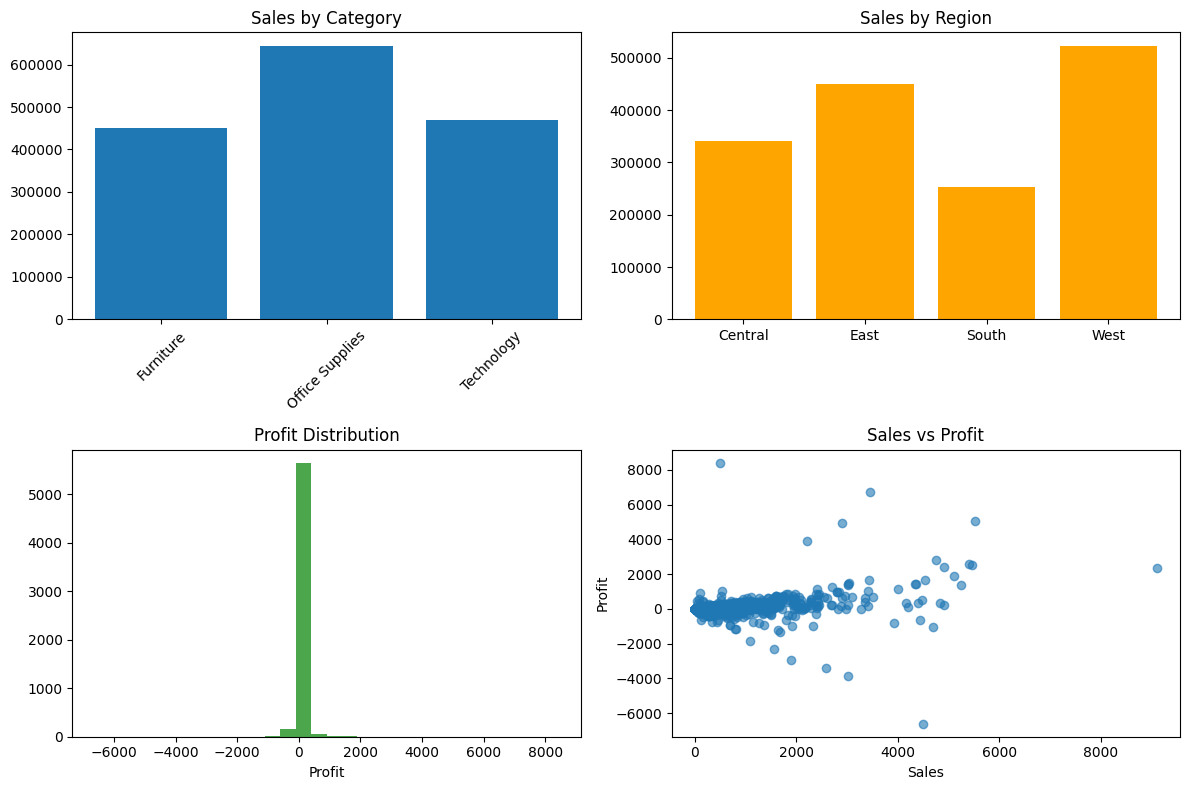

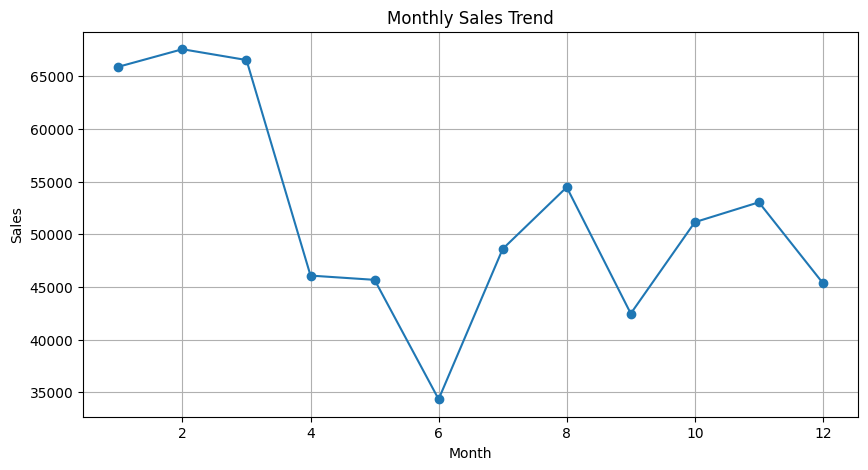


✅ Cleaned data exported to 'cleaned_sales_data.csv'
✅ Analysis completed successfully!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/SuperStore_Sales_Dataset.csv")

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

# ================================
# BASIC DATA CLEANING
# ================================

print("\n=== DATA CLEANING ===")

print(f"Original shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

if 'Row ID+O6G3A1:R6' in df.columns:
    df = df.rename(columns={'Row ID+O6G3A1:R6': 'Row_ID'})

df.columns = df.columns.str.strip().str.replace(' ', '_')
print(f"Cleaned columns: {list(df.columns)}")

print(f"\nMissing values before cleaning:")
print(df.isnull().sum())

df = df.replace('#N/A', np.nan)

if 'Returns' in df.columns:
    df['Returns'] = df['Returns'].fillna('No')

empty_cols = [col for col in ['ind1', 'ind2'] if col in df.columns and df[col].isnull().all()]
if empty_cols:
    df = df.drop(columns=empty_cols)
    print(f"Dropped empty columns: {empty_cols}")

date_cols = [col for col in df.columns if 'Date' in col]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

numeric_cols = ['Sales', 'Quantity', 'Profit']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

df = df.drop_duplicates()

if 'Quantity' in df.columns:
    df = df[df['Quantity'] > 0]

print(f"\nFinal shape after cleaning: {df.shape}")
print(f"Missing values after cleaning:")
print(df.isnull().sum())

# ================================
# BASIC ANALYTICS
# ================================

print("\n=== BASIC ANALYTICS ===")

print("Basic Statistics:")
print(df[['Sales', 'Quantity', 'Profit']].describe())

if 'Sales' in df.columns:
    print(f"\nTotal Revenue: ${df['Sales'].sum():,.2f}")
    print(f"Average Order Value: ${df['Sales'].mean():.2f}")

if 'Profit' in df.columns:
    print(f"Total Profit: ${df['Profit'].sum():,.2f}")
    print(f"Profit Margin: {(df['Profit'].sum()/df['Sales'].sum()*100):.2f}%")

if 'Category' in df.columns:
    print(f"\nTop Categories by Sales:")
    top_categories = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
    print(top_categories)

if 'Region' in df.columns:
    print(f"\nTop Regions by Sales:")
    top_regions = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
    print(top_regions)

# ================================
# BASIC VISUALIZATIONS
# ================================

print("\n=== CREATING VISUALIZATIONS ===")

plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

if 'Category' in df.columns:
    category_sales = df.groupby('Category')['Sales'].sum()
    axes[0,0].bar(category_sales.index, category_sales.values)
    axes[0,0].set_title('Sales by Category')
    axes[0,0].tick_params(axis='x', rotation=45)

if 'Region' in df.columns:
    region_sales = df.groupby('Region')['Sales'].sum()
    axes[0,1].bar(region_sales.index, region_sales.values, color='orange')
    axes[0,1].set_title('Sales by Region')

if 'Profit' in df.columns:
    axes[1,0].hist(df['Profit'], bins=30, alpha=0.7, color='green')
    axes[1,0].set_title('Profit Distribution')
    axes[1,0].set_xlabel('Profit')

if 'Sales' in df.columns and 'Profit' in df.columns:
    axes[1,1].scatter(df['Sales'], df['Profit'], alpha=0.6)
    axes[1,1].set_title('Sales vs Profit')
    axes[1,1].set_xlabel('Sales')
    axes[1,1].set_ylabel('Profit')

plt.tight_layout()
plt.show()

if 'Order_Date' in df.columns:
    df['Month'] = df['Order_Date'].dt.month
    monthly_sales = df.groupby('Month')['Sales'].sum()

    plt.figure(figsize=(10, 5))
    plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
    plt.title('Monthly Sales Trend')
    plt.xlabel('Month')
    plt.ylabel('Sales')
    plt.grid(True)
    plt.show()

# ================================
# EXPORT CLEANED DATA
# ================================

# Save cleaned dataset
df.to_csv('cleaned_sales_data.csv', index=False)
print("\n Cleaned data exported to 'cleaned_sales_data.csv'")
print("Analysis completed successfully!")